<style>
.rtl-block {
  direction: rtl;
  text-align: right;
}
.rtl-block h1, .rtl-block h2, .rtl-block h3,
.rtl-block h4, .rtl-block p, .rtl-block li,
.rtl-block blockquote, .rtl-block th, .rtl-block td {
  text-align: right;
}
.rtl-block table {
  direction: rtl;
  margin-right: 0;
  margin-left: auto;
}
.rtl-block pre, .rtl-block code, .rtl-block .MathJax {
  direction: ltr;
  unicode-bidi: embed;
}
</style>

<div class="rtl-block" dir="rtl" style="text-align: right;" markdown="1">

# מטלה בלמידת מכונה: סיווג סוגי שאלות

**Dataset:** [TREC Question Classification](https://www.kaggle.com/datasets/thedevastator/the-trec-question-classification-dataset-a-longi)  
**סוג למידה:** סיווג רב-מחלקתי  
**אלגוריתם במימוש עצמי:** K-Nearest Neighbors with Cosine Similarity  
**מדד מרכזי:** Macro-average F1


</div>

<div dir="rtl">

## פרטי הסטודנטים ותיעוד השימוש ב-AI

### פרטי הסטודנטים

יש לרשום רק שם פרטי, האות הראשונה של שם המשפחה וארבע הספרות האחרונות של תעודת הזהות.

- סטודנט/ית 1:  אופק ו. ;  5922
- סטודנט/ית 2:  אליאור פ. ;  5389
- סטודנט/ית 3:  שירה ר. ;  5023

### שימוש ב-AI

במהלך העבודה נעזרנו ב-ChatGPT ככלי עזר להבנת דרישות המטלה, לבחירת ה-Dataset,כנון שלבי הניסוי ולסיוע בכתיבת הקוד ופתרון באגים. בנוסף, התייעצנו איתו לגבי השוואת התוצאות בין המודלים השונים וביקשנו רעיונות לניסוח המסקנות שלנו.  

הפרומפטים העיקריים שבהם השתמשנו ומטרת כל שימוש מפורטים בטבלה שלהלן:

### הפרומפטים שבהם השתמשנו

| # | הפרומפט ששאלנו | מטרת השימוש |
|---:|---|---|
| 1 | **"קיבלנו מטלה בלמידת מכונה לסיווג טקסט למספר מחלקות. אילו שלבים מרכזיים (Pipeline) כדאי לכלול כדי לעמוד בדרישות של עיבוד נתונים, אימון ובדיקה?"** | הבנת דרישות המטלה ותכנון נכון של שלבי העבודה בקוד. |
| 2 | **"אנחנו רוצים לעשות את המטלה על ניתוח טקסט ולא על תמונות. איזה Datasets מומלצים יש ב-Kaggle לבעיות סיווג שהן לא בינאריות (multi-class)?"** | חיפוש נתונים שיתאימו להגדרות המטלה. |
| 3 | **"ראינו שמישהו כבר עשה על SMS Spam, אז בחרנו ב-TREC Question Classification. איך הכי נכון לחלץ ולמפות את 6 התוויות הראשיות מתוך הקובץ שם?"** | אימות שהנתונים שבחרנו טובים, והבנה איך לסדר את קטגוריות המטרה (Labels). |
| 4 | **"בגלל ההתפלגות של המחלקות ב-TREC, האם Macro-average F1 זה המדד הנכון להשתמש בו כמו שמבקשים במטלה? ואיזה עוד גרפים כדאי לעשות בשלב ה-EDA?"** | ביסוס מדד האיכות שלנו וקבלת רעיונות להצגת נתונים בשלב ההיכרות. |
| 5 | **"לשלב ה-Feature Engineering, חוץ מ-TF-IDF רגיל על מילים ותווים, איזה עוד פיצ'רים מעניינים אפשר להוציא מהשאלות? למשל אורך השאלה, אם יש בה מספרים וכו'?"** | חשיבה על יצירת מאפיינים חדשים כדי לשפר את המודל שלנו. |
| 6 | **"אנחנו מנסים לממש בעצמנו אלגוריתם KNN עם Cosine Similarity ומטריצות Sparse כדי לקבל בונוס. איך עושים נרמול לוקטורים לפני שמחשבים את המרחקים ביניהם?"** | עזרה בקוד ובמתמטיקה של בניית אלגוריתם הלמידה מאפס. |
| 7 | **"אנחנו כותבים פונקציה שעושה Grid Search עם 5-fold CV. איך אנחנו מוודאים שלא תהיה לנו זליגת מידע (Data Leakage) כשאנחנו משתמשים ב-Random Oversampling כדי לאזן את הנתונים?"** | עזרה במימוש לולאת האימון ככה שלא יהיו לנו באגים מבלבלים בגלל כפילויות של נתונים. |
| 8 | **"הרצנו את הקוד ושמנו לב שבקובץ מ-Kaggle חלק מהתוויות מופיעות כמספרים במקום טקסט. איך כדאי לתקן את המיפוי בפונקציה שטוענת את הנתונים?"** | פתרון באג שגילינו תוך כדי עבודה עם קובץ ה-CSV. |
| 9 | **"לסעיף ההרחבות (בונוס), אנחנו רוצים להראות השוואה בין הפרמטרים מה-Grid Search. איך כדאי לארגן את זה ב-DataFrame כדי שיהיה קל לראות מה תרם הכי הרבה למודל?"** | התייעצות לגבי סידור טבלאות התוצאות בצורה שתהיה ברורה לבודק. |
| 10 | **"ראינו שהפיצ'רים שיצרנו באמת משפרים את המודל, אבל צריך למצוא את המשקל (Scale) הנכון בשבילם. איך אפשר לבדוק את זה רק על נתוני האימון בלי לגעת ב-Test?"** | תכנון שלב בחירת היפר-פרמטר נוסף בצורה שלא תהרוס את סט הבדיקה שלנו. |
| 11 | **"הרצנו את המודל הסופי על ה-Test set וקיבלנו Macro-F1 של 0.8489. יש לך רעיון איך אפשר להסביר את החיזויים (Explainability) על בסיס השכנים הקרובים שהמודל מצא?"** | ניתוח פלטי החיזוי הסופיים שלנו כדי לענות על דרישת סעיף ההסברתיות (Explainability). |


### עזרים וקישורים נוספים

- <span dir="ltr">[TREC Question Classification ב-Kaggle](https://www.kaggle.com/datasets/thedevastator/the-trec-question-classification-dataset-a-longi)</span> - מקור ה-Dataset וקובצי ה-train/test.
- <span dir="ltr">[עותק ציבורי של קובצי TREC](https://github.com/thtrieu/qclass_dl/tree/master/data)</span> - שימש אותנו כדי לאמת שהנתונים וסוגי התוויות מסודרים נכון.
- <span dir="ltr">`assignment_ml_w_image_or_text_full_instructions_doc-2026c(1).pdf`</span> - המסמך המקורי עם הנחיות המטלה.
- <span dir="ltr">`sms_spam_classifier_work.ipynb`</span> - מחברת דוגמה שהייתה לנו; השתמשנו בה רק כדי להבין את המבנה הכללי וכדי לוודא שלא בחרנו את אותו נושא בטעות, ללא העתקת קוד.

</div>

<div class="rtl-block" dir="rtl" style="text-align: right;" markdown="1">

## מבנה המחברת לפי סעיפי המטלה

1. **מבוא והצגת הבעיה והנתונים**
2. **עיבוד מוקדם ו-Feature Engineering**
3. **אלגוריתם הלמידה במימוש עצמי**
4. **אימון ובחירת Hyperparameters**
5. **חיזוי והערכת איכות על סט המבחן**
6. **הרחבות (Bonus): Grid מורחב, איזון נתונים ו-Explainability**


</div>

<div class="rtl-block" dir="rtl" style="text-align: right;" markdown="1">

## חלק 1 — מבוא: תיאור הבעיה וה-Dataset

מטרת העבודה היא לזהות איזה **סוג תשובה** נדרש כדי לענות על שאלה באנגלית. לדוגמה, השאלה “Who invented the telephone?” דורשת תשובה מסוג אדם, ואילו “Where is the Eiffel Tower?” דורשת תשובה מסוג מקום.

אנו משתמשים בשש התוויות הגסות של TREC:

| תווית | משמעות | דוגמה לסוג תשובה |
|---|---|---|
| `ABBR` | Abbreviation | קיצור או פירוש של ראשי תיבות |
| `ENTY` | Entity | חפץ, חומר, חיה או ישות אחרת |
| `DESC` | Description | הגדרה, תיאור, סיבה או אופן |
| `HUM` | Human | אדם, קבוצה או ארגון |
| `LOC` | Location | מדינה, עיר או מקום |
| `NUM` | Numeric | מספר, תאריך, מרחק, מחיר או כמות |

ה-Dataset כולל `train.csv` ו-`test.csv` מתויגים מראש. לא נבצע חלוקת train/test חדשה. כל בחירת Feature Engineering ו-hyperparameters תתבצע בעזרת Stratified 5-fold cross-validation על `train.csv` בלבד. ה-test יישאר סגור עד לבחירת הקומבינציה הסופית.

משום שמדובר בסיווג רב-מחלקתי ללא מחלקה מרכזית יחידה, מדד האיכות הראשי הוא `macro-F1`: מחשבים F1 לכל מחלקה בנפרד ומבצעים ממוצע שווה בין המחלקות.

</div>

<div class="rtl-block" dir="rtl" style="text-align: right;" markdown="1">

### 1.1 התקנה וייבוא ספריות

התא הבא מתקין `kagglehub`, המשמש כגיבוי להורדת Dataset ציבורי מ-Kaggle כאשר קובצי הנתונים המקומיים אינם זמינים.

</div>

In [ ]:
try:
    import kagglehub
    print("kagglehub is already available.")
except ImportError:
    get_ipython().run_line_magic("pip", "-q install kagglehub")
    import kagglehub
    print("kagglehub was installed.")

kagglehub is already available.


In [ ]:
import re
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import ParameterGrid, StratifiedKFold

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_colwidth", 140)
sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

print("Environment ready.")


Environment ready.


<div class="rtl-block" dir="rtl" style="text-align: right;" markdown="1">

### 1.2 טעינת train ו-test

הקוד משתמש תחילה בעותק המקומי של `train.csv` ו-`test.csv`. אם הוא אינו זמין (למשל בהרצה חדשה ב-Colab), הקוד מוריד את ה-Dataset מ-Kaggle ומאתר את שני הקבצים לפי שמם, ללא תלות בנתיב cache מסוים. הוא גם מטפל באפשרות שהתוויות נשמרו כמספרים במקום כמחרוזות.

</div>

In [ ]:
DATASET_HANDLE = "thedevastator/the-trec-question-classification-dataset-a-longi"
LOCAL_DATA_DIR = Path("data/trec")

if (LOCAL_DATA_DIR / "train.csv").exists() and (LOCAL_DATA_DIR / "test.csv").exists():
    DATA_DIR = LOCAL_DATA_DIR
    print("Using local canonical TREC files.")
else:
    import kagglehub

    DATA_DIR = Path(kagglehub.dataset_download(DATASET_HANDLE))
    print("Downloaded TREC files from Kaggle.")

COARSE_LABELS = ["ABBR", "ENTY", "DESC", "HUM", "LOC", "NUM"]
# Kaggle version 2 stores the six coarse labels as integers in this order.
# This order is not alphabetical and therefore must not be inferred with enumerate.
NUMERIC_TO_COARSE = {
    0: "DESC",
    1: "ENTY",
    2: "ABBR",
    3: "HUM",
    4: "NUM",
    5: "LOC",
}


def find_dataset_file(filename, root=DATA_DIR):
    matches = list(root.rglob(filename))
    if len(matches) != 1:
        raise FileNotFoundError(
            f"Expected exactly one {filename!r} under {root}, found {len(matches)}: {matches}"
        )
    return matches[0]


def normalize_coarse_label(value):
    value_as_text = str(value).strip().upper()
    if value_as_text in COARSE_LABELS:
        return value_as_text
    try:
        numeric_value = int(float(value_as_text))
    except ValueError as exc:
        raise ValueError(f"Unknown coarse label: {value!r}") from exc
    if numeric_value not in NUMERIC_TO_COARSE:
        raise ValueError(f"Unknown numeric coarse label: {numeric_value}")
    return NUMERIC_TO_COARSE[numeric_value]


def load_trec_split(path):
    df = pd.read_csv(path)
    required_columns = {"label-coarse", "label-fine", "text"}
    missing = required_columns - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in {path.name}: {sorted(missing)}")
    df = df[["text", "label-coarse", "label-fine"]].copy()
    df = df.rename(
        columns={"label-coarse": "label", "label-fine": "fine_label"}
    )
    df["text"] = df["text"].astype(str).str.strip()
    df["label"] = df["label"].map(normalize_coarse_label)
    return df


train_path = find_dataset_file("train.csv")
test_path = find_dataset_file("test.csv")
train_df = load_trec_split(train_path)
test_df = load_trec_split(test_path)

# Semantic guardrails catch a wrong numeric-label mapping immediately.
semantic_sanity_cases = {
    "How did serfdom develop in and then leave Russia ?": "DESC",
    "What films featured the character Popeye Doyle ?": "ENTY",
    "What is the full form of .com ?": "ABBR",
    "What team did baseball 's St. Louis Browns become ?": "HUM",
    "When was Ozzy Osbourne born ?": "NUM",
    "What sprawling U.S. state boasts the most airports ?": "LOC",
}
for known_question, expected_label in semantic_sanity_cases.items():
    matching_labels = set(
        train_df.loc[
            train_df["text"] == known_question,
            "label",
        ]
    )
    if matching_labels and matching_labels != {expected_label}:
        raise AssertionError(
            f"Label mapping check failed for {known_question!r}: "
            f"expected {expected_label}, received {sorted(matching_labels)}"
        )

for split_name, split_df in {"train": train_df, "test": test_df}.items():
    assert not split_df[["text", "label"]].isna().any().any()
    assert (split_df["text"].str.len() > 0).all()
    assert set(split_df["label"]) == set(COARSE_LABELS)
    print(f"{split_name:>5}: {split_df.shape[0]:,} rows, {split_df.shape[1]} columns")

print(f"\nDataset directory: {DATA_DIR}")

Using local canonical TREC files.
train: 5,452 rows, 3 columns
 test: 500 rows, 3 columns

Dataset directory: data/trec


In [ ]:
print("First five training rows:")
display(train_df.head(5))

print(
    "The test set was loaded and validated structurally, but its examples are "
    "not displayed before model selection."
)

First five training rows:
The test set was loaded and validated structurally, but its examples are not displayed before model selection.


,text,label,fine_label
0,How did serfdom develop in and then leave Russia ?,DESC,0
1,What films featured the character Popeye Doyle ?,ENTY,1
2,How can I find a list of celebrities ' real names ?,DESC,0
3,What fowl grabs the spotlight after the Chinese Year of the Monkey ?,ENTY,2
4,What is the full form of .com ?,ABBR,3


<div class="rtl-block" dir="rtl" style="text-align: right;" markdown="1">

### 1.3 היכרות עם הנתונים (EDA) ומדד האיכות

נבחן את גודל המחלקות, את אורכי השאלות ואת מילות הפתיחה. מידע זה מסביר מדוע Macro-F1 מתאים ומניע את יצירת מאפייני השאלה הייעודיים.

</div>

,label,count,percent
0,ABBR,86,1.58
1,ENTY,1250,22.93
2,DESC,1162,21.31
3,HUM,1223,22.43
4,LOC,835,15.32
5,NUM,896,16.43


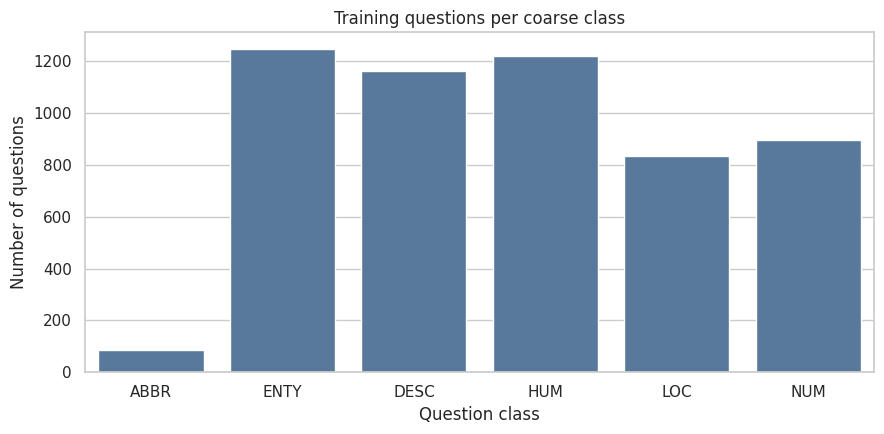

In [ ]:
train_distribution = (
    train_df["label"]
    .value_counts()
    .reindex(COARSE_LABELS)
    .rename_axis("label")
    .reset_index(name="count")
)
train_distribution["percent"] = (
    100 * train_distribution["count"] / len(train_df)
).round(2)
display(train_distribution)

plt.figure(figsize=(9, 4.5))
sns.barplot(data=train_distribution, x="label", y="count", color="#4C78A8")
plt.title("Training questions per coarse class")
plt.xlabel("Question class")
plt.ylabel("Number of questions")
plt.tight_layout()
plt.show()


word_count            character_count            
            mean median max            mean median  max
label                                                  
ABBR         8.0    7.0  18            37.4   31.0   96
DESC         8.8    8.0  37            41.7   38.0  196
ENTY        10.8   10.0  31            53.4   50.0  172
HUM         11.2   11.0  34            56.8   54.0  194
LOC         10.0   10.0  29            51.0   48.0  156
NUM         10.4   10.0  29            50.8   48.0  148

,count
prefix,
what,3242
how,764
who,559
where,273
when,131
which,105
why,103
name,90
in,66


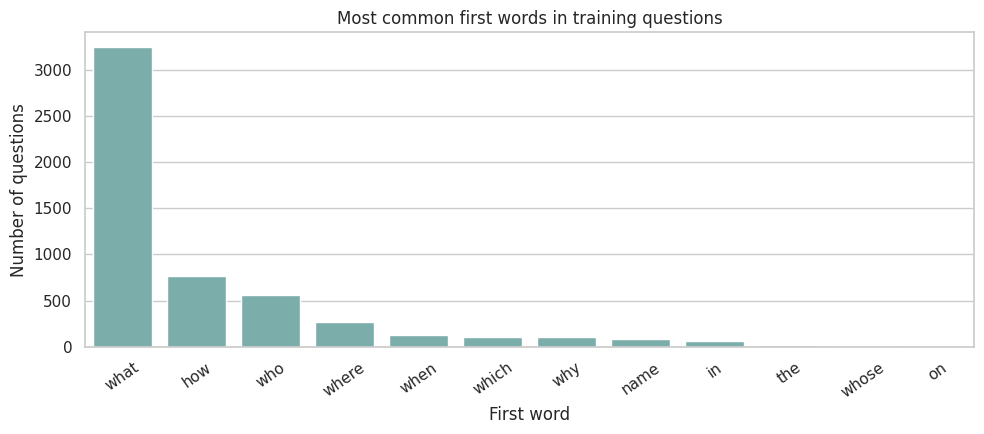

In [ ]:
def extract_question_prefix(text):
    match = re.search(r"[A-Za-z]+", str(text).lower())
    return match.group(0) if match else "other"


length_df = train_df.assign(
    word_count=train_df["text"].str.split().str.len(),
    character_count=train_df["text"].str.len(),
    prefix=train_df["text"].map(extract_question_prefix),
)

display(
    length_df.groupby("label")[["word_count", "character_count"]]
    .agg(["mean", "median", "max"])
    .round(1)
)

top_prefixes = length_df["prefix"].value_counts().head(12)
display(top_prefixes.rename("count").to_frame())

plt.figure(figsize=(10, 4.5))
sns.barplot(x=top_prefixes.index, y=top_prefixes.values, color="#72B7B2")
plt.title("Most common first words in training questions")
plt.xlabel("First word")
plt.ylabel("Number of questions")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()


<div class="rtl-block" dir="rtl" style="text-align: right;" markdown="1">

## חלק 2 — עיבוד מוקדם ו-Feature Engineering

נשווה שלושה היבטים של Feature Engineering:

1. **Word TF-IDF מול Character TF-IDF** - מילים וביטויי שתי מילים לעומת רצפי תווים בתוך גבולות מילים. Character n-grams יכולים לזהות תבניות כמו `who`, `where`, סיומות ושגיאות כתיב.
2. **גודל אוצר המילים** - עד 4,000 לעומת עד 8,000 מאפיינים.
3. **מאפייני שאלה ייעודיים** - אורך, נוכחות מספרים, מילת פתיחה, `how many`, רמז לקיצור ורמז להגדרה.

בניקוי הטקסט נהפוך לאותיות קטנות, נחליף מספרים בסמן `numbertoken`, נסיר פיסוק ונאחד רווחים. מספרים אינם נמחקים לחלוטין מפני שהם רמז חשוב למחלקה `NUM`.

מאפייני השאלה מוכפלים תחילה ב-`0.35`. בניגוד לעץ החלטה, ב-KNN הסקאלה משפיעה על דמיון הקוסינוס ולכן אין להתייחס לערך זה כבחירה שרירותית: לאחר ה-grid הראשי נבצע בדיקת רגישות ממוקדת למספר ערכי scale, בעזרת `train.csv` בלבד, ונבחר את הערך לפי 5-fold CV לפני פתיחת ה-test.

</div>

In [ ]:
NUMBER_PATTERN = re.compile(r"\b\d+(?:[.,]\d+)?\b")
NON_LETTER_PATTERN = re.compile(r"[^a-z\s']+")
WHITESPACE_PATTERN = re.compile(r"\s+")
WORD_TOKEN_PATTERN = r"(?u)\b[a-z][a-z']+\b"

QUESTION_PREFIXES = ["what", "who", "where", "when", "why", "how", "which", "name"]
QUESTION_FEATURE_NAMES = [
    "q__word_count_scaled",
    "q__character_count_scaled",
    "q__contains_digit",
    "q__how_many_or_much",
    "q__abbreviation_cue",
    "q__definition_cue",
    *[f"q__starts_{prefix}" for prefix in QUESTION_PREFIXES],
    "q__starts_other",
]
QUESTION_FEATURE_SCALE = 0.35
QUESTION_FEATURE_SCALE_CANDIDATES = [0.10, 0.20, 0.35, 0.50, 0.70, 1.00]


def normalize_text(text):
    text = str(text).lower()
    text = NUMBER_PATTERN.sub(" numbertoken ", text)
    text = NON_LETTER_PATTERN.sub(" ", text)
    return WHITESPACE_PATTERN.sub(" ", text).strip()


def question_feature_values(text):
    raw = str(text)
    lowered = raw.lower().strip()
    words = re.findall(r"[a-z]+", lowered)
    prefix = words[0] if words else "other"
    values = [
        min(len(words) / 25.0, 1.0),
        min(len(raw) / 150.0, 1.0),
        float(any(character.isdigit() for character in raw)),
        float("how many" in lowered or "how much" in lowered),
        float(
            "stand for" in lowered
            or "abbreviation" in lowered
            or "acronym" in lowered
        ),
        float(
            lowered.startswith("what is")
            or lowered.startswith("what are")
            or lowered.startswith("define")
        ),
        *[float(prefix == candidate) for candidate in QUESTION_PREFIXES],
        float(prefix not in QUESTION_PREFIXES),
    ]
    return values


def question_feature_matrix(texts, scale=QUESTION_FEATURE_SCALE):
    values = np.asarray(
        [question_feature_values(text) for text in texts],
        dtype=float,
    )
    return sparse.csr_matrix(values * float(scale))


def question_feature_record(text):
    values = question_feature_values(text)
    return {
        name: round(float(value), 3)
        for name, value in zip(QUESTION_FEATURE_NAMES, values)
        if value > 0
    }


def make_vectorizer(config):
    common = dict(
        preprocessor=normalize_text,
        lowercase=False,
        min_df=2,
        max_features=int(config["max_features"]),
        sublinear_tf=True,
        norm="l2",
        strip_accents="unicode",
    )
    if config["representation"] == "word":
        return TfidfVectorizer(
            **common,
            analyzer="word",
            token_pattern=WORD_TOKEN_PATTERN,
            ngram_range=(1, 2),
        )
    if config["representation"] == "char":
        return TfidfVectorizer(
            **common,
            analyzer="char_wb",
            ngram_range=(3, 5),
        )
    raise ValueError(f"Unknown representation: {config['representation']}")


def fit_feature_pipeline(train_texts, config):
    train_texts = np.asarray(train_texts, dtype=object)
    vectorizer = make_vectorizer(config)
    X_text = vectorizer.fit_transform(train_texts)
    if bool(config["use_question_features"]):
        question_feature_scale = float(
            config.get("question_feature_scale", QUESTION_FEATURE_SCALE)
        )
        X = sparse.hstack(
            [X_text, question_feature_matrix(train_texts, question_feature_scale)],
            format="csr",
        )
    else:
        X = X_text.tocsr()
    return vectorizer, X


def transform_feature_pipeline(vectorizer, texts, config):
    texts = np.asarray(texts, dtype=object)
    X_text = vectorizer.transform(texts)
    if bool(config["use_question_features"]):
        question_feature_scale = float(
            config.get("question_feature_scale", QUESTION_FEATURE_SCALE)
        )
        return sparse.hstack(
            [X_text, question_feature_matrix(texts, question_feature_scale)],
            format="csr",
        )
    return X_text.tocsr()


def complete_feature_names(vectorizer, config):
    names = vectorizer.get_feature_names_out().astype(object)
    if bool(config["use_question_features"]):
        names = np.concatenate([names, np.asarray(QUESTION_FEATURE_NAMES, dtype=object)])
    return names

In [ ]:
def preprocessing_examples(df, split_name, n=3):
    sample = df.head(n).copy()
    sample.insert(0, "split", split_name)
    sample["clean_text"] = sample["text"].map(normalize_text)
    sample["question_features"] = sample["text"].map(question_feature_record)
    return sample[["split", "label", "text", "clean_text", "question_features"]]


# During model development we demonstrate preprocessing on train rows only.
# Test examples are shown later, after every model-selection decision is fixed.
preprocessing_demo = preprocessing_examples(train_df, "train", n=6)
display(preprocessing_demo)

,split,label,text,clean_text,question_features
0,train,DESC,How did serfdom develop in and then leave Russia ?,how did serfdom develop in and then leave russia,"{'q__word_count_scaled': 0.36, 'q__character_count_scaled': 0.333, 'q__starts_how': 1.0}"
1,train,ENTY,What films featured the character Popeye Doyle ?,what films featured the character popeye doyle,"{'q__word_count_scaled': 0.28, 'q__character_count_scaled': 0.32, 'q__starts_what': 1.0}"
2,train,DESC,How can I find a list of celebrities ' real names ?,how can i find a list of celebrities ' real names,"{'q__word_count_scaled': 0.4, 'q__character_count_scaled': 0.34, 'q__starts_how': 1.0}"
3,train,ENTY,What fowl grabs the spotlight after the Chinese Year of the Monkey ?,what fowl grabs the spotlight after the chinese year of the monkey,"{'q__word_count_scaled': 0.48, 'q__character_count_scaled': 0.453, 'q__starts_what': 1.0}"
4,train,ABBR,What is the full form of .com ?,what is the full form of com,"{'q__word_count_scaled': 0.28, 'q__character_count_scaled': 0.207, 'q__definition_cue': 1.0, 'q__starts_what': 1.0}"
5,train,HUM,What contemptible scoundrel stole the cork from my lunch ?,what contemptible scoundrel stole the cork from my lunch,"{'q__word_count_scaled': 0.36, 'q__character_count_scaled': 0.387, 'q__starts_what': 1.0}"


In [ ]:
demo_config = {
    "representation": "word",
    "max_features": 4_000,
    "use_question_features": True,
}
demo_texts = preprocessing_demo["text"].to_numpy()
demo_vectorizer, demo_matrix = fit_feature_pipeline(demo_texts, demo_config)
demo_feature_names = complete_feature_names(demo_vectorizer, demo_config)


def strongest_features(row, feature_names, top_n=12):
    row = row.tocsr()
    if row.nnz == 0:
        return []
    order = np.argsort(row.data)[::-1][:top_n]
    return [
        (str(feature_names[row.indices[index]]), round(float(row.data[index]), 3))
        for index in order
    ]


demo_output = preprocessing_demo[["split", "label", "text"]].copy()
demo_output["strongest_features"] = [
    strongest_features(demo_matrix[index], demo_feature_names)
    for index in range(demo_matrix.shape[0])
]
display(demo_output)


,split,label,text,strongest_features
0,train,DESC,How did serfdom develop in and then leave Russia ?,"[(how, 1.0), (q__starts_how, 0.35), (q__word_count_scaled, 0.126), (q__character_count_scaled, 0.117)]"
1,train,ENTY,What films featured the character Popeye Doyle ?,"[(what, 0.707), (the, 0.707), (q__starts_what, 0.35), (q__character_count_scaled, 0.112), (q__word_count_scaled, 0.098)]"
2,train,DESC,How can I find a list of celebrities ' real names ?,"[(how, 0.764), (of, 0.645), (q__starts_how, 0.35), (q__word_count_scaled, 0.14), (q__character_count_scaled, 0.119)]"
3,train,ENTY,What fowl grabs the spotlight after the Chinese Year of the Monkey ?,"[(the, 0.807), (of, 0.449), (what, 0.384), (q__starts_what, 0.35), (q__word_count_scaled, 0.168), (q__character_count_scaled, 0.159)]"
4,train,ABBR,What is the full form of .com ?,"[(of, 0.636), (the, 0.545), (what, 0.545), (q__starts_what, 0.35), (q__definition_cue, 0.35), (q__word_count_scaled, 0.098), (q__charact..."
5,train,HUM,What contemptible scoundrel stole the cork from my lunch ?,"[(what, 0.707), (the, 0.707), (q__starts_what, 0.35), (q__character_count_scaled, 0.135), (q__word_count_scaled, 0.126)]"


<div class="rtl-block" dir="rtl" style="text-align: right;" markdown="1">

## חלק 3 — אלגוריתם הלמידה: K-Nearest Neighbors במימוש עצמי

KNN אינו בונה נוסחה פרמטרית בזמן האימון; פונקציית `train` שומרת את דוגמאות האימון ואת התוויות. בזמן החיזוי מנרמלים כל וקטור לאורך 1 ומחשבים Cosine Similarity:

$$\operatorname{cosine}(x,z)=\frac{x\cdot z}{\lVert x\rVert_2\lVert z\rVert_2}$$

לאחר מכן בוחרים את $k$ השכנים הדומים ביותר ומצביעים על המחלקה:

- `uniform` - לכל שכן קול אחד.
- `similarity` - קולו של שכן משוקלל לפי מידת הדמיון שלו לשאלה.

החישוב מתבצע במטריצות sparse וב-batches כדי לא ליצור בבת אחת מטריצת דמיון גדולה מדי. המימוש אינו משתמש ב-`KNeighborsClassifier` של scikit-learn.

</div>

In [ ]:
class SparseCosineKNN:
    '''KNN for non-negative sparse text features, implemented from scratch.'''

    def __init__(self, n_neighbors=5, weights="uniform", batch_size=256):
        if int(n_neighbors) < 1:
            raise ValueError("n_neighbors must be at least 1")
        if weights not in {"uniform", "similarity"}:
            raise ValueError("weights must be 'uniform' or 'similarity'")
        self.n_neighbors = int(n_neighbors)
        self.weights = weights
        self.batch_size = int(batch_size)

    @staticmethod
    def _as_nonnegative_csr(X):
        X = X.tocsr().astype(float) if sparse.issparse(X) else sparse.csr_matrix(X, dtype=float)
        if X.nnz and np.min(X.data) < 0:
            raise ValueError("Cosine KNN expects non-negative features")
        return X

    @classmethod
    def _row_normalize(cls, X):
        X = cls._as_nonnegative_csr(X)
        squared_norms = np.asarray(X.multiply(X).sum(axis=1)).ravel()
        norms = np.sqrt(squared_norms)
        inverse_norms = np.divide(
            1.0,
            norms,
            out=np.zeros_like(norms, dtype=float),
            where=norms > 0,
        )
        return sparse.diags(inverse_norms) @ X

    def train(self, X, y):
        X = self._as_nonnegative_csr(X)
        y = np.asarray(y)
        if X.shape[0] != y.shape[0]:
            raise ValueError("X and y must have the same number of rows")
        if X.shape[0] == 0:
            raise ValueError("Cannot train on an empty dataset")

        self.X_train_normalized_ = self._row_normalize(X).tocsr()
        self.y_train_ = y.copy()
        self.classes_, counts = np.unique(y, return_counts=True)
        self.class_prior_ = counts / counts.sum()
        self.n_features_in_ = X.shape[1]
        return self

    fit = train

    def _check_fitted(self):
        if not hasattr(self, "X_train_normalized_"):
            raise RuntimeError("Call train before predict")

    def kneighbors(self, X, n_neighbors=None):
        self._check_fitted()
        X = self._as_nonnegative_csr(X)
        if X.shape[1] != self.n_features_in_:
            raise ValueError(
                f"Expected {self.n_features_in_} features, received {X.shape[1]}"
            )

        requested_k = self.n_neighbors if n_neighbors is None else int(n_neighbors)
        k = min(requested_k, self.X_train_normalized_.shape[0])
        if k < 1:
            raise ValueError("n_neighbors must be at least 1")

        X_normalized = self._row_normalize(X).tocsr()
        all_similarities = []
        all_indices = []

        for start in range(0, X_normalized.shape[0], self.batch_size):
            stop = min(start + self.batch_size, X_normalized.shape[0])
            similarities = (
                X_normalized[start:stop] @ self.X_train_normalized_.T
            ).toarray()

            candidate_indices = np.argpartition(
                -similarities,
                kth=k - 1,
                axis=1,
            )[:, :k]
            candidate_similarities = np.take_along_axis(
                similarities,
                candidate_indices,
                axis=1,
            )
            order = np.argsort(-candidate_similarities, axis=1)
            sorted_indices = np.take_along_axis(candidate_indices, order, axis=1)
            sorted_similarities = np.take_along_axis(
                candidate_similarities,
                order,
                axis=1,
            )
            all_indices.append(sorted_indices)
            all_similarities.append(sorted_similarities)

        return np.vstack(all_similarities), np.vstack(all_indices)

    def predict_from_neighbors(
        self,
        neighbor_indices,
        neighbor_similarities,
        n_neighbors=None,
        weights=None,
    ):
        self._check_fitted()
        k = self.n_neighbors if n_neighbors is None else int(n_neighbors)
        weighting = self.weights if weights is None else weights
        if weighting not in {"uniform", "similarity"}:
            raise ValueError("Unknown weighting method")
        k = min(k, neighbor_indices.shape[1])

        indices = neighbor_indices[:, :k]
        similarities = neighbor_similarities[:, :k]
        neighbor_labels = self.y_train_[indices]
        if weighting == "uniform":
            vote_weights = np.ones_like(similarities, dtype=float)
        else:
            vote_weights = np.clip(similarities, 0.0, None) + 1e-12

        scores = np.zeros((indices.shape[0], len(self.classes_)), dtype=float)
        for class_index, class_label in enumerate(self.classes_):
            scores[:, class_index] = (
                (neighbor_labels == class_label) * vote_weights
            ).sum(axis=1)

        # Tiny prior-based tie breaker, without changing non-tied decisions.
        scores += self.class_prior_[None, :] * 1e-12
        return self.classes_[np.argmax(scores, axis=1)]

    def predict(self, X):
        similarities, indices = self.kneighbors(X, self.n_neighbors)
        return self.predict_from_neighbors(
            indices,
            similarities,
            n_neighbors=self.n_neighbors,
            weights=self.weights,
        )


In [ ]:
toy_questions = np.array(
    [
        "What does CPU stand for?",
        "What is the abbreviation for kilometer?",
        "What animal is known as man's best friend?",
        "What instrument has black and white keys?",
        "What is photosynthesis?",
        "Why is the sky blue?",
        "Who invented the telephone?",
        "Who was the first president?",
        "Where is Mount Everest?",
        "Which country contains Paris?",
        "How many days are in a year?",
        "When was the moon landing?",
    ],
    dtype=object,
)
toy_labels = np.array(
    ["ABBR", "ABBR", "ENTY", "ENTY", "DESC", "DESC", "HUM", "HUM", "LOC", "LOC", "NUM", "NUM"]
)
toy_config = {
    "representation": "word",
    "max_features": 4_000,
    "use_question_features": True,
}
toy_vectorizer, toy_X = fit_feature_pipeline(toy_questions, toy_config)
toy_model = SparseCosineKNN(n_neighbors=1, weights="uniform").train(toy_X, toy_labels)
toy_predictions = toy_model.predict(toy_X)
toy_similarities, toy_indices = toy_model.kneighbors(toy_X[:2], n_neighbors=3)

assert np.array_equal(toy_predictions, toy_labels)
assert toy_indices.shape == (2, 3)
assert toy_similarities.shape == (2, 3)
assert np.all(toy_similarities[:, 0] >= toy_similarities[:, 1])
print("KNN sanity test passed.")


KNN sanity test passed.


<div class="rtl-block" dir="rtl" style="text-align: right;" markdown="1">

## חלק 4 — אימון ובחירת Hyperparameters

### 4.1 Grid Search מלא עם Stratified 5-fold CV

נבדוק את המכפלה הקרטזית המלאה:

- 2 ייצוגים: Word TF-IDF / Character TF-IDF.
- 2 גדלי אוצר מילים: 4,000 / 8,000.
- 2 אפשרויות למאפייני שאלה: ללא / עם.
- 2 אפשרויות איזון: ללא / Random Oversampling.
- 3 ערכי `k`: 3 / 5 / 9.
- 2 שיטות הצבעה: uniform / similarity.

מתקבלות 96 קומבינציות, שכל אחת מוערכת בחמישה folds — סך הכול 480 הערכות. ה-vectorizer מותאם מחדש רק על ארבעת חלקי האימון בכל fold, ו-oversampling מתבצע רק לאחר מכן ורק על אותו חלק אימון. כך נמנעת דליפת מידע.

כדי לקצר את זמן הריצה בלי לשנות את הניסוי, עבור אותו fold ואותה תצורת Feature Engineering אנו מוצאים פעם אחת את תשעת השכנים הקרובים ואז משתמשים בהם להערכת ערכי `k` ושיטות ההצבעה השונות.

החיפוש המורחב מממש גם את דרישות הרחבות 6א–6ב. הוא מוצג ומורץ כאן משום שתוצאותיו קובעות את המודל הסופי, ולכן מבחינה מתודולוגית עליו להסתיים לפני חלק 5 ולפני השימוש ב-test.

</div>

In [ ]:
def random_oversample(X, y, random_state=RANDOM_STATE, return_indices=False):
    '''Duplicate minority-class rows until all classes match the majority count.'''
    X = X.tocsr() if sparse.issparse(X) else sparse.csr_matrix(X)
    y = np.asarray(y)
    rng = np.random.default_rng(random_state)
    classes, counts = np.unique(y, return_counts=True)
    target_count = int(counts.max())
    sampled_indices = []

    for class_label, class_count in zip(classes, counts):
        class_indices = np.flatnonzero(y == class_label)
        sampled_indices.extend(class_indices.tolist())
        missing = target_count - int(class_count)
        if missing > 0:
            sampled_indices.extend(
                rng.choice(class_indices, size=missing, replace=True).tolist()
            )

    sampled_indices = np.asarray(sampled_indices, dtype=int)
    rng.shuffle(sampled_indices)
    result = (X[sampled_indices], y[sampled_indices])
    if return_indices:
        return (*result, sampled_indices)
    return result


def run_grid_search(
    training_df,
    feature_configurations,
    k_values,
    weight_values,
    sampling_values,
    n_splits=5,
    random_state=RANDOM_STATE,
    verbose=True,
):
    texts = training_df["text"].to_numpy(dtype=object)
    labels = training_df["label"].to_numpy()
    splitter = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    )
    folds = list(splitter.split(texts, labels))
    max_k = max(k_values)
    rows = []
    started = time.perf_counter()

    for feature_id, feature_config in enumerate(feature_configurations):
        for fold_number, (train_indices, validation_indices) in enumerate(folds, start=1):
            fold_train_texts = texts[train_indices]
            fold_validation_texts = texts[validation_indices]
            y_fold_train = labels[train_indices]
            y_fold_validation = labels[validation_indices]

            vectorizer, X_fold_train = fit_feature_pipeline(
                fold_train_texts,
                feature_config,
            )
            X_fold_validation = transform_feature_pipeline(
                vectorizer,
                fold_validation_texts,
                feature_config,
            )
            vocabulary_size = len(vectorizer.get_feature_names_out())

            for sampling_method in sampling_values:
                if sampling_method == "random_oversample":
                    X_for_fit, y_for_fit = random_oversample(
                        X_fold_train,
                        y_fold_train,
                        random_state=random_state + fold_number,
                    )
                elif sampling_method == "none":
                    X_for_fit, y_for_fit = X_fold_train, y_fold_train
                else:
                    raise ValueError(f"Unknown sampling method: {sampling_method}")

                search_model = SparseCosineKNN(
                    n_neighbors=max_k,
                    weights="uniform",
                ).train(X_for_fit, y_for_fit)
                neighbor_similarities, neighbor_indices = search_model.kneighbors(
                    X_fold_validation,
                    n_neighbors=max_k,
                )

                for k_value in k_values:
                    for weight_method in weight_values:
                        predictions = search_model.predict_from_neighbors(
                            neighbor_indices,
                            neighbor_similarities,
                            n_neighbors=k_value,
                            weights=weight_method,
                        )
                        rows.append(
                            {
                                "feature_id": feature_id,
                                **feature_config,
                                "sampling": sampling_method,
                                "n_neighbors": k_value,
                                "weights": weight_method,
                                "fold": fold_number,
                                "macro_f1": f1_score(
                                    y_fold_validation,
                                    predictions,
                                    average="macro",
                                ),
                                "vocabulary_size": vocabulary_size,
                            }
                        )

        if verbose:
            print(
                f"Completed feature configuration {feature_id + 1}/"
                f"{len(feature_configurations)}"
            )

    raw_results = pd.DataFrame(rows)
    group_columns = [
        "feature_id",
        "representation",
        "max_features",
        "use_question_features",
        "sampling",
        "n_neighbors",
        "weights",
    ]
    summary = (
        raw_results.groupby(group_columns, dropna=False)
        .agg(
            macro_f1_mean=("macro_f1", "mean"),
            macro_f1_std=("macro_f1", "std"),
            fold_scores=("macro_f1", lambda values: [round(float(v), 6) for v in values]),
            mean_vocabulary_size=("vocabulary_size", "mean"),
        )
        .reset_index()
        .sort_values(
            ["macro_f1_mean", "macro_f1_std"],
            ascending=[False, True],
        )
        .reset_index(drop=True)
    )
    summary["runtime_seconds_total"] = round(time.perf_counter() - started, 2)
    return raw_results, summary


In [ ]:
feature_grid = {
    "representation": ["word", "char"],
    "max_features": [4_000, 8_000],
    "use_question_features": [False, True],
}
feature_configurations = list(ParameterGrid(feature_grid))
K_VALUES = [3, 5, 9]
WEIGHT_VALUES = ["uniform", "similarity"]
SAMPLING_VALUES = ["none", "random_oversample"]

number_of_permutations = (
    len(feature_configurations)
    * len(K_VALUES)
    * len(WEIGHT_VALUES)
    * len(SAMPLING_VALUES)
)
print(f"Feature configurations: {len(feature_configurations)}")
print(f"Complete permutations: {number_of_permutations}")
print(f"Total fold evaluations: {number_of_permutations * 5}")


Feature configurations: 8
Complete permutations: 96
Total fold evaluations: 480


In [ ]:
cv_raw_results, cv_summary = run_grid_search(
    train_df,
    feature_configurations=feature_configurations,
    k_values=K_VALUES,
    weight_values=WEIGHT_VALUES,
    sampling_values=SAMPLING_VALUES,
    n_splits=5,
    random_state=RANDOM_STATE,
    verbose=True,
)
cv_raw_results.to_csv("trec_knn_cv_raw_results.csv", index=False)
cv_summary.to_csv("trec_knn_cv_summary.csv", index=False)

display_columns = [
    "feature_id",
    "representation",
    "max_features",
    "use_question_features",
    "sampling",
    "n_neighbors",
    "weights",
    "macro_f1_mean",
    "macro_f1_std",
    "fold_scores",
    "mean_vocabulary_size",
]
display(cv_summary[display_columns])

best_row = cv_summary.iloc[0]
best_config = {
    "representation": str(best_row["representation"]),
    "max_features": int(best_row["max_features"]),
    "use_question_features": bool(best_row["use_question_features"]),
    "sampling": str(best_row["sampling"]),
    "n_neighbors": int(best_row["n_neighbors"]),
    "weights": str(best_row["weights"]),
}
best_cv_score = float(best_row["macro_f1_mean"])
grid_best_cv_score = best_cv_score

print("\nBest permutation:")
print(best_config)
print(f"Mean 5-fold validation macro-F1: {best_cv_score:.4f}")

Completed feature configuration 1/8
Completed feature configuration 2/8
Completed feature configuration 3/8
Completed feature configuration 4/8
Completed feature configuration 5/8
Completed feature configuration 6/8
Completed feature configuration 7/8
Completed feature configuration 8/8

Best permutation:
{'representation': 'word', 'max_features': 8000, 'use_question_features': True, 'sampling': 'none', 'n_neighbors': 5, 'weights': 'similarity'}
Mean 5-fold validation macro-F1: 0.8167


,feature_id,representation,max_features,use_question_features,sampling,n_neighbors,weights,macro_f1_mean,macro_f1_std,fold_scores,mean_vocabulary_size
0,5,word,8000,True,none,5,similarity,0.816706,0.004242,"[0.81717, 0.816128, 0.822755, 0.816674, 0.810802]",5847.0
1,1,word,4000,True,none,9,similarity,0.812246,0.014256,"[0.789811, 0.813698, 0.826722, 0.809305, 0.821693]",4000.0
2,5,word,8000,True,none,9,similarity,0.810681,0.012926,"[0.807299, 0.827749, 0.814351, 0.812039, 0.791966]",5847.0
3,5,word,8000,True,none,5,uniform,0.810101,0.004636,"[0.808414, 0.817182, 0.80949, 0.804456, 0.810962]",5847.0
4,1,word,4000,True,none,5,similarity,0.809044,0.008800,"[0.802483, 0.798061, 0.819072, 0.815742, 0.809861]",4000.0
...,...,...,...,...,...,...,...,...,...,...,...
91,2,char,4000,False,random_oversample,9,uniform,0.594223,0.016172,"[0.607324, 0.58511, 0.59762, 0.60993, 0.571132]",4000.0
92,6,char,8000,False,random_oversample,9,similarity,0.592478,0.017997,"[0.604546, 0.573498, 0.603093, 0.608932, 0.572321]",8000.0
93,6,char,8000,False,random_oversample,5,uniform,0.587498,0.013769,"[0.590361, 0.581059, 0.597803, 0.601161, 0.567106]",8000.0
94,6,char,8000,False,random_oversample,3,uniform,0.586445,0.012176,"[0.593688, 0.584514, 0.598852, 0.588215, 0.566957]",8000.0


Average and best CV score by representation:
Average and best CV score by use_question_features:
Average and best CV score by sampling:
Average and best CV score by n_neighbors:
Average and best CV score by weights:


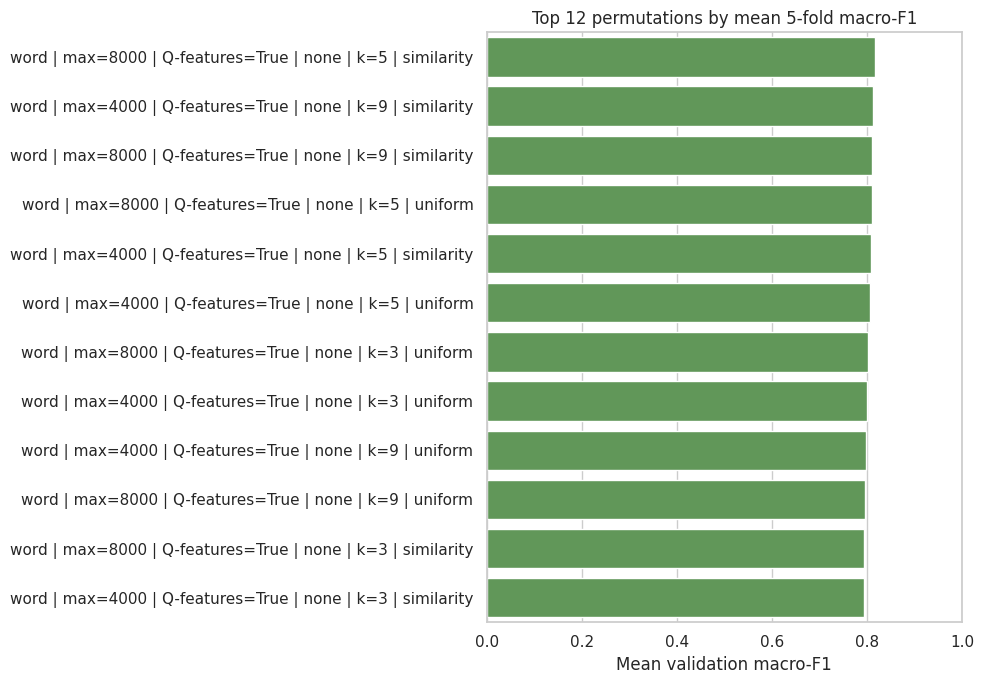

,mean,max,std,count
representation,,,,
word,0.7531,0.8167,0.0477,48
char,0.6520,0.7085,0.0401,48


,mean,max,std,count
use_question_features,,,,
True,0.7363,0.8167,0.0527,48
False,0.6688,0.7845,0.0631,48


,mean,max,std,count
sampling,,,,
none,0.7252,0.8167,0.0668,48
random_oversample,0.6799,0.7772,0.0599,48


,mean,max,std,count
n_neighbors,,,,
5,0.7056,0.8167,0.0688,32
9,0.7019,0.8122,0.0702,32
3,0.7002,0.8014,0.0641,32


,mean,max,std,count
weights,,,,
similarity,0.7069,0.8167,0.0661,48
uniform,0.6982,0.8101,0.0685,48


In [ ]:
top_results = cv_summary.head(12).copy()
top_results["configuration"] = top_results.apply(
    lambda row: (
        f"{row['representation']} | max={int(row['max_features'])} | "
        f"Q-features={bool(row['use_question_features'])} | "
        f"{row['sampling']} | k={int(row['n_neighbors'])} | {row['weights']}"
    ),
    axis=1,
)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_results,
    y="configuration",
    x="macro_f1_mean",
    color="#59A14F",
)
plt.title("Top 12 permutations by mean 5-fold macro-F1")
plt.xlabel("Mean validation macro-F1")
plt.ylabel("")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

for comparison_column in ["representation", "use_question_features", "sampling", "n_neighbors", "weights"]:
    print(f"Average and best CV score by {comparison_column}:")
    comparison = (
        cv_summary.groupby(comparison_column)["macro_f1_mean"]
        .agg(["mean", "max", "std", "count"])
        .sort_values("max", ascending=False)
    )
    display(comparison.round(4))


<div class="rtl-block" dir="rtl" style="text-align: right;" markdown="1">

### 4.2 השוואות מבוקרות ובדיקת רגישות למשקל מאפייני השאלה

טבלת ה-grid מאפשרת לבצע **ablation מבוקר** ללא הרצות נוספות: מתחילים מהקומבינציה הזוכה, משנים בכל שורה גורם אחד בלבד ומשאירים את הייצוג, גודל אוצר המילים, האיזון, $k$ ושיטת ההצבעה קבועים. כל ההשוואות משתמשות באותם חמישה folds.

לאחר מכן נבדוק בנפרד את `QUESTION_FEATURE_SCALE`. זהו שלב ממוקד שני של בחירת hyperparameter: שאר הקומבינציה נשארת קבועה, ה-vectorizer מותאם מחדש בתוך כל fold, וה-test עדיין אינו בשימוש. כך ניתן להצדיק את משקל המאפיינים על סמך נתוני האימון ולא על סמך תחושת בטן.

</div>

In [ ]:
BASE_CONFIGURATION_FIELDS = [
    "representation",
    "max_features",
    "use_question_features",
    "sampling",
    "n_neighbors",
    "weights",
]


def cv_row_for(overrides=None):
    """Return one grid row after changing only the requested fields."""
    configuration = {
        field: best_config[field]
        for field in BASE_CONFIGURATION_FIELDS
    }
    configuration.update(overrides or {})
    mask = pd.Series(True, index=cv_summary.index)
    for field, value in configuration.items():
        mask &= cv_summary[field].eq(value)
    matches = cv_summary.loc[mask]
    if len(matches) != 1:
        raise AssertionError(
            f"Expected one CV row for {configuration}, found {len(matches)}"
        )
    return matches.iloc[0]


alternative_values = {
    "representation": "char" if best_config["representation"] == "word" else "word",
    "max_features": 4_000 if best_config["max_features"] == 8_000 else 8_000,
    "use_question_features": not best_config["use_question_features"],
    "sampling": (
        "random_oversample"
        if best_config["sampling"] == "none"
        else "none"
    ),
}
factor_names = {
    "representation": "Text representation",
    "max_features": "Vocabulary cap",
    "use_question_features": "Question features",
    "sampling": "Sampling",
}

chosen_grid_row = cv_row_for()
controlled_rows = []
for factor, alternative_value in alternative_values.items():
    alternative_row = cv_row_for({factor: alternative_value})
    controlled_rows.append(
        {
            "factor_changed": factor_names[factor],
            "chosen_value": best_config[factor],
            "comparison_value": alternative_value,
            "chosen_macro_f1": float(chosen_grid_row["macro_f1_mean"]),
            "comparison_macro_f1": float(alternative_row["macro_f1_mean"]),
            "delta_for_chosen": (
                float(chosen_grid_row["macro_f1_mean"])
                - float(alternative_row["macro_f1_mean"])
            ),
            "chosen_fold_scores": chosen_grid_row["fold_scores"],
            "comparison_fold_scores": alternative_row["fold_scores"],
        }
    )

controlled_ablation_df = pd.DataFrame(controlled_rows)
controlled_ablation_display = controlled_ablation_df.copy()
for score_column in [
    "chosen_macro_f1",
    "comparison_macro_f1",
    "delta_for_chosen",
]:
    controlled_ablation_display[score_column] = (
        controlled_ablation_display[score_column].round(4)
    )
display(controlled_ablation_display)

controlled_deltas = controlled_ablation_df.set_index(
    "factor_changed"
)["delta_for_chosen"].to_dict()

,factor_changed,chosen_value,comparison_value,chosen_macro_f1,comparison_macro_f1,delta_for_chosen,chosen_fold_scores,comparison_fold_scores
0,Text representation,word,char,0.8167,0.6980,0.1187,"[0.81717, 0.816128, 0.822755, 0.816674, 0.810802]","[0.717521, 0.684683, 0.699339, 0.707561, 0.680833]"
1,Vocabulary cap,8000,4000,0.8167,0.8090,0.0077,"[0.81717, 0.816128, 0.822755, 0.816674, 0.810802]","[0.802483, 0.798061, 0.819072, 0.815742, 0.809861]"
2,Question features,True,False,0.8167,0.7684,0.0483,"[0.81717, 0.816128, 0.822755, 0.816674, 0.810802]","[0.763049, 0.774373, 0.774869, 0.783775, 0.745818]"
3,Sampling,none,random_oversample,0.8167,0.7743,0.0424,"[0.81717, 0.816128, 0.822755, 0.816674, 0.810802]","[0.767495, 0.775252, 0.771598, 0.785714, 0.771264]"


Base-grid CV score at scale 0.35: 0.8167
Selected question-feature scale: 0.35
Selected mean 5-fold validation macro-F1: 0.8167


,question_feature_scale,macro_f1_mean,macro_f1_std,fold_scores
0,0.35,0.8167,0.0042,"[0.81717, 0.816128, 0.822755, 0.816674, 0.810802]"
1,0.50,0.8126,0.0063,"[0.803078, 0.815298, 0.820213, 0.813763, 0.810779]"
2,0.70,0.8105,0.0104,"[0.796312, 0.81787, 0.823187, 0.807023, 0.808125]"
3,1.00,0.7996,0.0110,"[0.786891, 0.815381, 0.803122, 0.800718, 0.791974]"
4,0.20,0.7975,0.0062,"[0.792715, 0.79967, 0.800879, 0.804587, 0.78945]"
5,0.10,0.7906,0.0090,"[0.780039, 0.799654, 0.793065, 0.797933, 0.782313]"


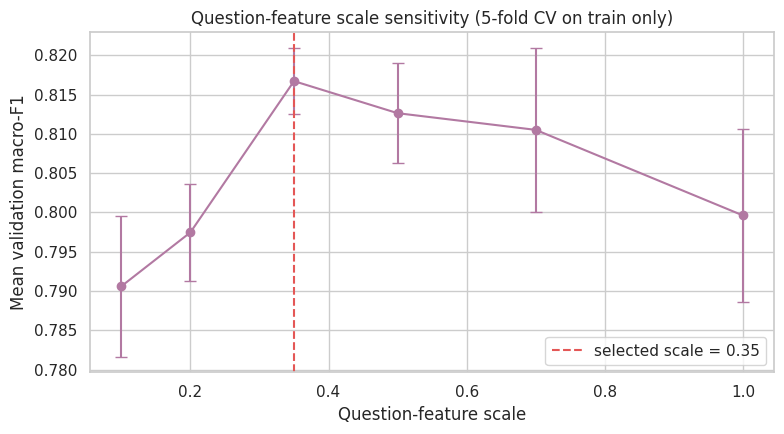

In [ ]:
def evaluate_question_feature_scales(
    training_df,
    base_config,
    scale_values,
    n_splits=5,
    random_state=RANDOM_STATE,
):
    """Evaluate only the feature scale while every other choice stays fixed."""
    texts = training_df["text"].to_numpy(dtype=object)
    labels = training_df["label"].to_numpy()
    splitter = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    )
    folds = list(splitter.split(texts, labels))
    rows = []

    for scale_value in scale_values:
        feature_config = {
            "representation": base_config["representation"],
            "max_features": base_config["max_features"],
            "use_question_features": True,
            "question_feature_scale": float(scale_value),
        }
        for fold_number, (train_indices, validation_indices) in enumerate(folds, start=1):
            vectorizer, X_fold_train = fit_feature_pipeline(
                texts[train_indices],
                feature_config,
            )
            X_fold_validation = transform_feature_pipeline(
                vectorizer,
                texts[validation_indices],
                feature_config,
            )
            y_fold_train = labels[train_indices]
            if base_config["sampling"] == "random_oversample":
                X_fold_train, y_fold_train = random_oversample(
                    X_fold_train,
                    y_fold_train,
                    random_state=random_state + fold_number,
                )

            model = SparseCosineKNN(
                n_neighbors=base_config["n_neighbors"],
                weights=base_config["weights"],
            ).train(X_fold_train, y_fold_train)
            predictions = model.predict(X_fold_validation)
            rows.append(
                {
                    "question_feature_scale": float(scale_value),
                    "fold": fold_number,
                    "macro_f1": f1_score(
                        labels[validation_indices],
                        predictions,
                        average="macro",
                    ),
                }
            )

    raw = pd.DataFrame(rows)
    summary = (
        raw.groupby("question_feature_scale")
        .agg(
            macro_f1_mean=("macro_f1", "mean"),
            macro_f1_std=("macro_f1", "std"),
            fold_scores=(
                "macro_f1",
                lambda values: [round(float(value), 6) for value in values],
            ),
        )
        .reset_index()
        .sort_values(
            ["macro_f1_mean", "macro_f1_std"],
            ascending=[False, True],
        )
        .reset_index(drop=True)
    )
    return raw, summary


if not bool(best_config["use_question_features"]):
    raise AssertionError("Scale sensitivity requires question features in the winning grid row")

scale_raw_results, scale_sensitivity_summary = evaluate_question_feature_scales(
    train_df,
    best_config,
    QUESTION_FEATURE_SCALE_CANDIDATES,
)
scale_sensitivity_display = scale_sensitivity_summary.copy()
scale_sensitivity_display["macro_f1_mean"] = (
    scale_sensitivity_display["macro_f1_mean"].round(4)
)
scale_sensitivity_display["macro_f1_std"] = (
    scale_sensitivity_display["macro_f1_std"].round(4)
)
display(scale_sensitivity_display)

selected_question_feature_scale = float(
    scale_sensitivity_summary.iloc[0]["question_feature_scale"]
)
best_config["question_feature_scale"] = selected_question_feature_scale
best_cv_score = float(scale_sensitivity_summary.iloc[0]["macro_f1_mean"])

scale_plot = scale_sensitivity_summary.sort_values("question_feature_scale")
plt.figure(figsize=(8, 4.5))
plt.errorbar(
    scale_plot["question_feature_scale"],
    scale_plot["macro_f1_mean"],
    yerr=scale_plot["macro_f1_std"],
    marker="o",
    capsize=4,
    color="#B279A2",
)
plt.axvline(
    selected_question_feature_scale,
    linestyle="--",
    color="#E45756",
    label=f"selected scale = {selected_question_feature_scale:.2f}",
)
plt.title("Question-feature scale sensitivity (5-fold CV on train only)")
plt.xlabel("Question-feature scale")
plt.ylabel("Mean validation macro-F1")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Base-grid CV score at scale {QUESTION_FEATURE_SCALE:.2f}: {grid_best_cv_score:.4f}")
print(f"Selected question-feature scale: {selected_question_feature_scale:.2f}")
print(f"Selected mean 5-fold validation macro-F1: {best_cv_score:.4f}")

<div class="rtl-block" dir="rtl" style="text-align: right;" markdown="1">

### 4.3 אימון הקומבינציה הטובה ביותר על כל ה-train

לאחר שהקומבינציה נבחרה לפי ה-grid והבדיקה הממוקדת של ה-scale—שתיהן על `train.csv` בלבד—מתאימים מחדש את ה-vectorizer על כל ה-train, מפעילים את אפשרות האיזון שנבחרה ומאמנים את KNN הסופי. נשמור גם את אינדקס המקור של כל שורה כדי שנוכל להסביר תחזיות באמצעות השאלות השכנות.

</div>

In [ ]:
final_feature_config = {
    "representation": best_config["representation"],
    "max_features": best_config["max_features"],
    "use_question_features": best_config["use_question_features"],
    "question_feature_scale": best_config["question_feature_scale"],
}
final_vectorizer, X_train_full = fit_feature_pipeline(
    train_df["text"].to_numpy(),
    final_feature_config,
)
y_train_full = train_df["label"].to_numpy()

if best_config["sampling"] == "random_oversample":
    X_train_for_fit, y_train_for_fit, fit_source_indices = random_oversample(
        X_train_full,
        y_train_full,
        random_state=RANDOM_STATE,
        return_indices=True,
    )
else:
    X_train_for_fit = X_train_full
    y_train_for_fit = y_train_full
    fit_source_indices = np.arange(len(train_df))

final_model = SparseCosineKNN(
    n_neighbors=best_config["n_neighbors"],
    weights=best_config["weights"],
).train(X_train_for_fit, y_train_for_fit)

actual_text_feature_count = len(final_vectorizer.get_feature_names_out())
actual_question_feature_count = (
    len(QUESTION_FEATURE_NAMES)
    if final_feature_config["use_question_features"]
    else 0
)
actual_total_feature_count = X_train_full.shape[1]

print("Best configuration:", best_config)
print(
    f"The 8,000 setting is an upper cap: the fitted vocabulary contains "
    f"{actual_text_feature_count:,} TF-IDF features after min_df=2; with "
    f"{actual_question_feature_count} question features, the final matrix has "
    f"{actual_total_feature_count:,} columns."
)
print("Original train matrix:", X_train_full.shape)
print("Matrix used by final KNN:", X_train_for_fit.shape)
print("Class counts used by final KNN:")
display(pd.Series(y_train_for_fit).value_counts().reindex(COARSE_LABELS).to_frame("count"))

Best configuration: {'representation': 'word', 'max_features': 8000, 'use_question_features': True, 'sampling': 'none', 'n_neighbors': 5, 'weights': 'similarity', 'question_feature_scale': 0.35}
The 8,000 setting is an upper cap: the fitted vocabulary contains 7,211 TF-IDF features after min_df=2; with 15 question features, the final matrix has 7,226 columns.
Original train matrix: (5452, 7226)
Matrix used by final KNN: (5452, 7226)
Class counts used by final KNN:


,count
ABBR,86
ENTY,1250
DESC,1162
HUM,1223
LOC,835
NUM,896


<div class="rtl-block" dir="rtl" style="text-align: right;" markdown="1">

## חלק 5 — חיזוי והערכת איכות על ה-test

רק בשלב זה ממירים את `test.csv` בעזרת ה-vectorizer שכבר הותאם ל-train. אין לבצע `fit` על ה-test ואין לשנות את התצורה בעקבות תוצאותיו.

</div>

In [ ]:
X_test = transform_feature_pipeline(
    final_vectorizer,
    test_df["text"].to_numpy(),
    final_feature_config,
)
y_test = test_df["label"].to_numpy()
test_predictions = final_model.predict(X_test)

test_macro_f1 = f1_score(y_test, test_predictions, average="macro")
test_accuracy = accuracy_score(y_test, test_predictions)

print(f"Test macro-F1: {test_macro_f1:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

first_five_predictions = test_df.head(5).copy()
first_five_predictions["predicted_label"] = test_predictions[:5]
first_five_predictions["correct"] = (
    first_five_predictions["label"] == first_five_predictions["predicted_label"]
)
display(first_five_predictions)


Test macro-F1: 0.8489
Test accuracy: 0.8500


,text,label,fine_label,predicted_label,correct
0,How far is it from Denver to Aspen ?,NUM,40,NUM,True
1,"What county is Modesto , California in ?",LOC,21,LOC,True
2,Who was Galileo ?,HUM,12,HUM,True
3,What is an atom ?,DESC,7,DESC,True
4,When did Hawaii become a state ?,NUM,8,NUM,True


,precision,recall,f1-score,support
ABBR,0.8000,0.8889,0.8421,9.00
ENTY,0.8769,0.6064,0.7170,94.00
DESC,0.7363,0.9710,0.8375,138.00
HUM,0.8551,0.9077,0.8806,65.00
LOC,0.9351,0.8889,0.9114,81.00
NUM,0.9794,0.8407,0.9048,113.00
accuracy,0.8500,0.8500,0.8500,0.85
macro avg,0.8638,0.8506,0.8489,500.00
weighted avg,0.8665,0.8500,0.8477,500.00


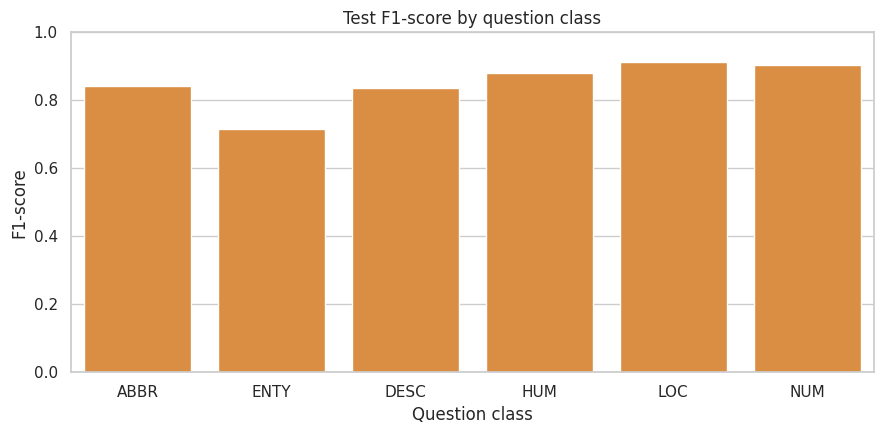

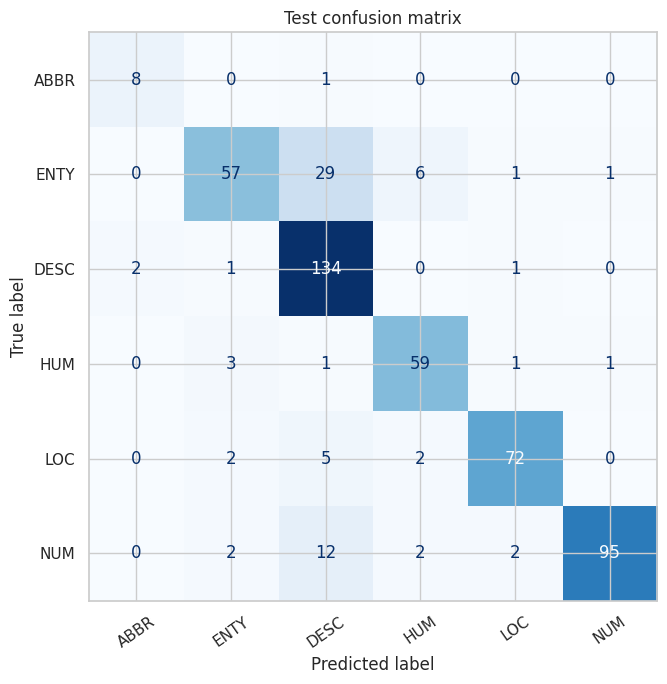

In [ ]:
report = classification_report(
    y_test,
    test_predictions,
    labels=COARSE_LABELS,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report).T
display(report_df.round(4))

class_rows = report_df.loc[COARSE_LABELS].reset_index(names="label")
plt.figure(figsize=(9, 4.5))
sns.barplot(data=class_rows, x="label", y="f1-score", color="#F28E2B")
plt.title("Test F1-score by question class")
plt.xlabel("Question class")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=COARSE_LABELS,
    cmap="Blues",
    xticks_rotation=35,
    ax=ax,
    colorbar=False,
)
ax.set_title("Test confusion matrix")
plt.tight_layout()
plt.show()


<div class="rtl-block" dir="rtl" style="text-align: right;" markdown="1">

### 5.1 הדגמת ה-Feature Engineering של הקומבינציה הזוכה

נציג שלוש דוגמאות מה-train ושלוש מה-test, כולל הטקסט הנקי והמאפיינים החזקים ביותר לפי הייצוג שנבחר.

</div>

In [ ]:
final_feature_names = complete_feature_names(
    final_vectorizer,
    final_feature_config,
)


def final_feature_examples(df, split_name, n=3, top_n=12):
    sample = df.head(n).copy()
    matrix = transform_feature_pipeline(
        final_vectorizer,
        sample["text"].to_numpy(),
        final_feature_config,
    )
    sample.insert(0, "split", split_name)
    sample["clean_text"] = sample["text"].map(normalize_text)
    sample["strongest_features"] = [
        strongest_features(matrix[index], final_feature_names, top_n=top_n)
        for index in range(matrix.shape[0])
    ]
    return sample[["split", "label", "text", "clean_text", "strongest_features"]]


winning_flow_examples = pd.concat(
    [
        final_feature_examples(train_df, "train"),
        final_feature_examples(test_df, "test"),
    ],
    ignore_index=True,
)
display(winning_flow_examples)


,split,label,text,clean_text,strongest_features
0,train,DESC,How did serfdom develop in and then leave Russia ?,how did serfdom develop in and then leave russia,"[(develop, 0.398), (in and, 0.398), (russia, 0.366), (and then, 0.358), (leave, 0.358), (q__starts_how, 0.35), (then, 0.342), (how did, ..."
1,train,ENTY,What films featured the character Popeye Doyle ?,what films featured the character popeye doyle,"[(featured the, 0.451), (the character, 0.424), (popeye, 0.424), (films, 0.406), (featured, 0.393), (q__starts_what, 0.35), (character, ..."
2,train,DESC,How can I find a list of celebrities ' real names ?,how can i find a list of celebrities ' real names,"[(celebrities, 0.388), (find list, 0.377), (list of, 0.355), (q__starts_how, 0.35), (list, 0.34), (real, 0.322), (names, 0.298), (how ca..."
3,test,NUM,How far is it from Denver to Aspen ?,how far is it from denver to aspen,"[(it from, 0.428), (far is, 0.428), (how far, 0.386), (is it, 0.377), (far, 0.377), (q__starts_how, 0.35), (it, 0.269), (from, 0.243), (..."
4,test,LOC,"What county is Modesto , California in ?",what county is modesto california in,"[(county is, 0.539), (what county, 0.539), (county, 0.451), (california, 0.402), (q__starts_what, 0.35), (in, 0.163), (is, 0.139), (what..."
5,test,HUM,Who was Galileo ?,who was galileo,"[(who was, 0.718), (who, 0.497), (was, 0.487), (q__starts_who, 0.35), (q__word_count_scaled, 0.042), (q__character_count_scaled, 0.04)]"


<div class="rtl-block" dir="rtl" style="text-align: right;" markdown="1">

## חלק 6 — הרחבות (Bonus)

### 6א — Grid משולב של Feature Engineering ו-Hyperparameters

בחלק 4 נבדקו כל 96 הצירופים האפשריים של ייצוג הטקסט, גודל אוצר המילים, מאפייני השאלה, שיטת האיזון, ערך $k$ ושיטת ההצבעה. כל צירוף הוערך בחמישה folds, ולכן בוצעו 480 הערכות. הקוד מוקם לפני ה-test כדי שהקומבינציה הסופית תיבחר ללא דליפת מידע.

### 6ב — התמודדות עם חוסר איזון

באותו grid הושוו `none` ו-`random_oversample`. ההשוואה המבוקרת הראתה שבניסוי זה עבודה ללא oversampling הייתה טובה יותר, ולכן המודל הסופי שומר על התפלגות האימון המקורית. פירוט המספרים מופיע בטבלת ה-ablation בחלק 4.2.

### 6ג — Explainability באמצעות השכנים הקרובים

ב-KNN ניתן להסביר תחזית באופן ישיר: מציגים את שאלות האימון הדומות ביותר, את המחלקות שלהן ואת Cosine Similarity. אם מופעל oversampling, מסירים כפילויות בתצוגה כדי להציג שאלות מקור שונות.

</div>

In [ ]:
def explain_test_prediction(test_index, number_of_unique_neighbors=5):
    search_k = min(
        max(30, number_of_unique_neighbors * 5),
        X_train_for_fit.shape[0],
    )
    similarities, neighbor_indices = final_model.kneighbors(
        X_test[test_index],
        n_neighbors=search_k,
    )

    rows = []
    seen_source_indices = set()
    for similarity, fitted_index in zip(similarities[0], neighbor_indices[0]):
        source_index = int(fit_source_indices[int(fitted_index)])
        if source_index in seen_source_indices:
            continue
        seen_source_indices.add(source_index)
        source_row = train_df.iloc[source_index]
        rows.append(
            {
                "similarity": round(float(similarity), 4),
                "neighbor_label": source_row["label"],
                "neighbor_question": source_row["text"],
            }
        )
        if len(rows) == number_of_unique_neighbors:
            break

    query_row = test_df.iloc[test_index]
    print(f"Test example {test_index + 1}")
    print("Question:", query_row["text"])
    print("True label:", query_row["label"])
    print("Predicted label:", test_predictions[test_index])
    display(pd.DataFrame(rows))


correct_indices = np.flatnonzero(test_predictions == y_test)
incorrect_indices = np.flatnonzero(test_predictions != y_test)
selected_example_indices = []
if len(correct_indices):
    selected_example_indices.append(int(correct_indices[0]))
selected_example_indices.extend(int(index) for index in incorrect_indices[:2])
if len(selected_example_indices) < 3:
    remaining = [
        int(index)
        for index in range(len(test_df))
        if int(index) not in selected_example_indices
    ]
    selected_example_indices.extend(remaining[: 3 - len(selected_example_indices)])

for example_index in selected_example_indices:
    explain_test_prediction(example_index, number_of_unique_neighbors=5)


Test example 1
Question: How far is it from Denver to Aspen ?
True label: NUM
Predicted label: NUM
Test example 8
Question: What is Australia 's national flower ?
True label: ENTY
Predicted label: DESC
Test example 12
Question: What person 's head is on a dime ?
True label: HUM
Predicted label: NUM


,similarity,neighbor_label,neighbor_question
0,0.9258,NUM,How far is it from Phoenix to Blythe ?
1,0.6904,NUM,How far is Yaroslavl from Moscow ?
2,0.6182,NUM,How far is London UK from California ?
3,0.5088,NUM,How many miles is it from NY to Austria ?
4,0.4696,NUM,"How many miles is it from London , England to Plymouth , England ?"


,similarity,neighbor_label,neighbor_question
0,0.7326,DESC,What is Australia Day ?
1,0.4090,NUM,How big is Australia ?
2,0.3981,DESC,What is a Certified Nurse Midwife ?
3,0.3973,DESC,What is a `` repeating voter '' ?
4,0.3971,DESC,What is a dangling participle ?


,similarity,neighbor_label,neighbor_question
0,0.3679,LOC,What airport is on the Piccadilly subway line ?
1,0.3591,DESC,What is Head Start ?
2,0.3455,NUM,How many grooves are on a dime 's edge ?
3,0.3429,NUM,How many grooves are on a dime ?
4,0.3397,ENTY,What computer operating system is on the most computers ?


<div class="rtl-block" dir="rtl" style="text-align: right;" markdown="1">

## סיכום ומסקנות

התא הראשון מרכז את המספרים החשובים. התא הדינמי שאחריו מנסח את המסקנות מחדש בכל הרצה על סמך התוצאות בפועל, כולל:

- התצורה שנבחרה והפער בין CV למבחן.
- השוואות מבוקרות שבהן משנים גורם אחד בלבד.
- בדיקת הרגישות שמצדיקה את משקל מאפייני השאלה.
- המחלקות החזקות, החלשות והבלבול הנפוץ ביותר.
- הסבר של תחזית שגויה בעזרת השכנים הקרובים.
- מגבלות התוקף של הניסוי.

</div>

In [ ]:
print("Selected configuration:", best_config)
print(f"Base-grid mean 5-fold validation macro-F1: {grid_best_cv_score:.4f}")
print(f"Final selected mean 5-fold validation macro-F1: {best_cv_score:.4f}")
print(f"Final test macro-F1: {test_macro_f1:.4f}")
print(f"Final test accuracy: {test_accuracy:.4f}")
print(
    "Generalization gap (selected CV mean minus test macro-F1): "
    f"{best_cv_score - test_macro_f1:+.4f}"
)

Selected configuration: {'representation': 'word', 'max_features': 8000, 'use_question_features': True, 'sampling': 'none', 'n_neighbors': 5, 'weights': 'similarity', 'question_feature_scale': 0.35}
Base-grid mean 5-fold validation macro-F1: 0.8167
Final selected mean 5-fold validation macro-F1: 0.8167
Final test macro-F1: 0.8489
Final test accuracy: 0.8500
Generalization gap (selected CV mean minus test macro-F1): -0.0322


In [ ]:
try:
    from IPython.display import Markdown
except ImportError:
    class Markdown:
        def __init__(self, value):
            self.value = value

        def _repr_markdown_(self):
            return self.value

        def __repr__(self):
            return self.value

from sklearn.metrics import confusion_matrix


def controlled_delta(factor_name):
    row = controlled_ablation_df.loc[
        controlled_ablation_df["factor_changed"] == factor_name
    ]
    if len(row) != 1:
        raise AssertionError(f"Missing controlled comparison for {factor_name}")
    return float(row.iloc[0]["delta_for_chosen"])


representation_delta = controlled_delta("Text representation")
question_feature_delta = controlled_delta("Question features")
sampling_delta = controlled_delta("Sampling")
vocabulary_delta = controlled_delta("Vocabulary cap")

class_f1 = report_df.loc[COARSE_LABELS, "f1-score"].astype(float)
strongest_class = str(class_f1.idxmax())
weakest_class = str(class_f1.idxmin())

confusion = confusion_matrix(y_test, test_predictions, labels=COARSE_LABELS)
off_diagonal = confusion.copy()
np.fill_diagonal(off_diagonal, 0)
true_index, predicted_index = np.unravel_index(
    int(np.argmax(off_diagonal)),
    off_diagonal.shape,
)
confused_true = COARSE_LABELS[true_index]
confused_predicted = COARSE_LABELS[predicted_index]
confused_count = int(off_diagonal[true_index, predicted_index])

incorrect_indices = np.flatnonzero(test_predictions != y_test)
if len(incorrect_indices):
    error_index = int(incorrect_indices[0])
    similarities, fitted_indices = final_model.kneighbors(
        X_test[error_index],
        n_neighbors=min(30, X_train_for_fit.shape[0]),
    )
    seen_sources = set()
    neighbor_label = None
    neighbor_question = None
    neighbor_similarity = float("nan")
    for similarity, fitted_index in zip(similarities[0], fitted_indices[0]):
        source_index = int(fit_source_indices[int(fitted_index)])
        if source_index in seen_sources:
            continue
        seen_sources.add(source_index)
        neighbor_row = train_df.iloc[source_index]
        neighbor_label = str(neighbor_row["label"])
        neighbor_question = str(neighbor_row["text"]).replace("`", "'")
        neighbor_similarity = float(similarity)
        break

    query = str(test_df.iloc[error_index]["text"]).replace("`", "'")
    explainability_text = (
        f"בדוגמה השגויה `{query}` התווית האמיתית הייתה {y_test[error_index]} "
        f"והמודל חזה {test_predictions[error_index]}; השכן הייחודי הקרוב ביותר, "
        f"`{neighbor_question}`, סומן {neighbor_label} בדמיון {neighbor_similarity:.3f}. "
        "הדוגמה מראה כיצד דמיון מילולי מקומי יכול להוביל לטעות סמנטית"
    )
else:
    explainability_text = (
        "לא נמצאו טעויות במבחן, והשכנים הקרובים בדוגמאות שנבדקו תמכו בתוויות האמיתיות"
    )

configuration_description = (
    f"{best_config['representation']} TF-IDF, עד {best_config['max_features']:,} מאפיינים, "
    f"מאפייני שאלה={'כן' if best_config['use_question_features'] else 'לא'} "
    f"(scale={best_config['question_feature_scale']:.2f}), "
    f"איזון={best_config['sampling']}, k={best_config['n_neighbors']} "
    f"והצבעה={best_config['weights']}"
)

scale_min = float(scale_sensitivity_summary["question_feature_scale"].min())
scale_max = float(scale_sensitivity_summary["question_feature_scale"].max())

conclusions = (
    '<div class="rtl-block" dir="rtl" style="text-align: right;" markdown="1">\n\n'
    "### מסקנות במילים שלנו\n\n"
    f"1. הקומבינציה הסופית הייתה {configuration_description}. 8,000 הוא גבול עליון; "
    f"בפועל המטריצה הסופית כללה {actual_total_feature_count:,} מאפיינים לאחר סינון "
    f"מונחים נדירים והוספת מאפייני השאלה. לאחר הבחירה על train בלבד התקבל Macro-F1 "
    f"ממוצע של {best_cv_score:.4f} ב-5-fold CV; על סט המבחן התקבלו Macro-F1 של "
    f"{test_macro_f1:.4f} ודיוק של {test_accuracy:.4f}.\n"
    f"2. בהשוואה מבוקרת שבה כל יתר הגורמים נשארו קבועים, הייצוג "
    f"`{best_config['representation']}` הוסיף {representation_delta:+.4f} Macro-F1 ביחס "
    f"לייצוג החלופי, והגדלת תקרת אוצר המילים הוסיפה {vocabulary_delta:+.4f}.\n"
    f"3. באותו סוג השוואה, מאפייני השאלה הוסיפו {question_feature_delta:+.4f}. "
    f"בדיקת רגישות נפרדת בין scale={scale_min:.2f} ל-{scale_max:.2f} בחרה "
    f"scale={best_config['question_feature_scale']:.2f}; לכן משקל המאפיינים נשען על CV "
    "ולא על ה-test או על בחירה שרירותית.\n"
    f"4. אפשרות האיזון שנבחרה (`{best_config['sampling']}`) הייתה טובה ב-"
    f"{sampling_delta:+.4f} מהחלופה כאשר כל שאר ההגדרות נשארו קבועות. מכאן שבניסוי זה "
    "שכפול דוגמאות מיעוט לא שיפר את ההצבעה המקומית של KNN.\n"
    f"5. המחלקה החזקה ביותר במבחן הייתה {strongest_class} עם "
    f"F1={class_f1[strongest_class]:.4f}, החלשה ביותר הייתה {weakest_class} עם "
    f"F1={class_f1[weakest_class]:.4f}, והבלבול הלא-אלכסוני הנפוץ ביותר היה "
    f"{confused_true}→{confused_predicted} ({confused_count} שאלות).\n"
    f"6. {explainability_text}. המגבלה העיקרית היא שה-Dataset קטן יחסית ומכיל שאלות "
    "באנגלית בלבד; בנוסף, בחירת הפרמטרים מבוססת על CV יחיד עם random state קבוע, ולכן "
    "אין להסיק ללא בדיקה נוספת שהביצועים יעברו לשפות, לתחומים או למדגמים אחרים."
)
conclusions += "\n\n</div>"
display(Markdown(conclusions))

<div class="rtl-block" dir="rtl" style="text-align: right;" markdown="1">

### מסקנות במילים שלנו

1. הקומבינציה הסופית הייתה word TF-IDF, עד 8,000 מאפיינים, מאפייני שאלה=כן (scale=0.35), איזון=none, k=5 והצבעה=similarity. 8,000 הוא גבול עליון; בפועל המטריצה הסופית כללה 7,226 מאפיינים לאחר סינון מונחים נדירים והוספת מאפייני השאלה. לאחר הבחירה על train בלבד התקבל Macro-F1 ממוצע של 0.8167 ב-5-fold CV; על סט המבחן התקבלו Macro-F1 של 0.8489 ודיוק של 0.8500.
2. בהשוואה מבוקרת שבה כל יתר הגורמים נשארו קבועים, הייצוג `word` הוסיף +0.1187 Macro-F1 ביחס לייצוג החלופי, והגדלת תקרת אוצר המילים הוסיפה +0.0077.
3. באותו סוג השוואה, מאפייני השאלה הוסיפו +0.0483. בדיקת רגישות נפרדת בין scale=0.10 ל-1.00 בחרה scale=0.35; לכן משקל המאפיינים נשען על CV ולא על ה-test או על בחירה שרירותית.
4. אפשרות האיזון שנבחרה (`none`) הייתה טובה ב-+0.0424 מהחלופה כאשר כל שאר ההגדרות נשארו קבועות. מכאן שבניסוי זה שכפול דוגמאות מיעוט לא שיפר את ההצבעה המקומית של KNN.
5. המחלקה החזקה ביותר במבחן הייתה LOC עם F1=0.9114, החלשה ביותר הייתה ENTY עם F1=0.7170, והבלבול הלא-אלכסוני הנפוץ ביותר היה ENTY→DESC (29 שאלות).
6. בדוגמה השגויה `What is Australia 's national flower ?` התווית האמיתית הייתה ENTY והמודל חזה DESC; השכן הייחודי הקרוב ביותר, `What is Australia Day ?`, סומן DESC בדמיון 0.733. הדוגמה מראה כיצד דמיון מילולי מקומי יכול להוביל לטעות סמנטית. המגבלה העיקרית היא שה-Dataset קטן יחסית ומכיל שאלות באנגלית בלבד; בנוסף, בחירת הפרמטרים מבוססת על CV יחיד עם random state קבוע, ולכן אין להסיק ללא בדיקה נוספת שהביצועים יעברו לשפות, לתחומים או למדגמים אחרים.

</div>